
# Análisis Descriptivo de Datos con Python

Este notebook tiene como objetivo aplicar técnicas de análisis exploratorio de datos sobre un conjunto de datos del Titanic, cubriendo los siguientes temas:

## 1. ¿Qué son las medidas de localización? ¿cómo se comportan ante valores atípicos?
Las **medidas de localización** nos permiten entender **dónde se concentran los datos** en una variable numérica. Es decir, nos indican una especie de "centro" o "tendencia central" de los valores observados.

Las principales son:

- **Media (promedio):**  
  Es el valor promedio. Se obtiene sumando todos los valores y dividiendo entre el número total de observaciones.  
  Fórmula:  
  
  $\text{Media} = \frac{x_1 + x_2 + \dots + x_n}{n}$
  

- **Mediana:**  
  Es el valor central cuando los datos están ordenados. Si hay un número par de datos, es el promedio de los dos centrales.  
  Es útil cuando hay valores extremos (outliers), porque **no se ve afectada por ellos**.

- **Moda:**  
  Es el valor que más veces se repite en un conjunto de datos. Puede haber más de una moda o ninguna si todos los valores son distintos.

## 2. ¿Qué es un valor atípico (outlier)?

Un **valor atípico** es un dato que se **aleja mucho de la mayoría de los valores**. Puede ser un error de registro, un caso muy especial o simplemente una observación rara.  
Ejemplo: si la mayoría de edades están entre 0 y 80, un valor como 250 podría ser un outlier.

### ¿Cómo afectan los outliers a nuestras medidas?

| Medida   | ¿Afectada por outliers? | Comentario |
|----------|--------------------------|------------|
| Media    | ✅ Sí                   | Se puede distorsionar fácilmente si hay valores muy grandes o muy pequeños |
| Mediana  | ❌ No                   | Es más robusta: solo depende del orden, no de los valores extremos |
| Moda     | ❌ Generalmente no       | Solo se ve afectada si los outliers se repiten mucho |


## 3. ¿Qué son las medidas de dispersión o variabilidad?
Nos dicen **cuánto varían los datos respecto a su media**.
- **Rango:** diferencia entre el valor máximo y el mínimo.
- **Desviación estándar:** promedio de las distancias de cada dato a la media.
- **Varianza:** cuadrado de la desviación estándar.

## 4. ¿Qué es la distribución de los datos?
La **distribución** muestra cómo se comportan los datos en su conjunto: si hay simetría, concentración, sesgo, etc. Podemos visualizarla con histogramas o diagramas de densidad.

## 5. ¿Qué son los cuartiles?
Dividen un conjunto de datos ordenado en **cuatro partes iguales**:
- **Q1 (1er cuartil):** 25% de los datos están por debajo
- **Q2 (mediana):** 50% de los datos están por debajo
- **Q3 (3er cuartil):** 75% de los datos están por debajo

Los cuartiles son útiles para detectar outliers y visualizar la dispersión con boxplots.


In [ ]:
for link in enlaces:
    response = requests.get(link)
    time.sleep(2)


## Carga y exploración inicial de los datos

In [ ]:
# Librerías

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración de matplotlib y seaborn
%matplotlib inline
sns.set_style(style='whitegrid')
sns.set_context(context='notebook')
plt.rcParams['figure.figsize'] = (11, 9.4)

# Definición de colores para las gráficas
sex_color = {
    'female': '#ffb3b3ff',
    'male': '#b3d9ff'
    }

embarked_color = {
    'Southampton': '#ffb3b3ff',
    'Cherbourg': '#b3d9ff'
    'Queenstown': '#b3ffb3ff'
    }

In [29]:
# Cargar los datos
df = pd.read_csv("titanic.csv")


# Exploración inicial
df.head()


,passenger_class,name,age,embarked,home_destination,sex,survive
0,1st,"Allen,MissElisabethWalton",29.0000,Southampton,"StLouis,MO",female,yes
1,1st,"Allison,MissHelenLoraine",2.0000,Southampton,"Montreal,PQ/Chesterville,ON",female,no
2,1st,"Allison,MrHudsonJoshuaCreighton",30.0000,Southampton,"Montreal,PQ/Chesterville,ON",male,no
3,1st,"Allison,MrsHudsonJ.C.(BessieWaldoDaniels)",25.0000,Southampton,"Montreal,PQ/Chesterville,ON",female,no
4,1st,"Allison,MasterHudsonTrevor",0.9167,Southampton,"Montreal,PQ/Chesterville,ON",male,yes


In [30]:
# Información general del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1313 entries, 0 to 1312
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   passenger_class   1313 non-null   object 
 1   name              1313 non-null   object 
 2   age               633 non-null    float64
 3   embarked          820 non-null    object 
 4   home_destination  755 non-null    object 
 5   sex               1313 non-null   object 
 6   survive           1313 non-null   object 
dtypes: float64(1), object(6)
memory usage: 71.9+ KB


In [ ]:
# Estadísticas descriptivas del DataFrame (Sin limpieza de datos)
df.describe(include='all')

,passenger_class,name,age,embarked,home_destination,sex,survive
count,1313,1313,633.000000,820,755,1313,1313
unique,3,1310,NaN,3,371,2,2
top,3rd,"Connolly,MissKate",NaN,Southampton,"NewYork,NY",male,no
freq,711,2,NaN,573,65,850,864
mean,NaN,NaN,31.194181,NaN,NaN,NaN,NaN
std,NaN,NaN,14.747525,NaN,NaN,NaN,NaN
min,NaN,NaN,0.166700,NaN,NaN,NaN,NaN
25%,NaN,NaN,21.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,30.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,41.000000,NaN,NaN,NaN,NaN


In [32]:
#Imprime los distintos valores de la columna 'passenger class'
print(df['passenger_class'].unique())      

['1st' '2nd' '3rd']


In [33]:
#Imprime los distintos valores de la columna 'home_destination'
print(df['home_destination'].unique())  

['StLouis,MO' 'Montreal,PQ/Chesterville,ON' 'NewYork,NY' 'Hudson,NY'
 'Belfast,NI' 'Bayside,Queens,NY' 'Montevideo,Uruguay' 'Paris,France'
 'Hessle,Yorks' 'Montreal,PQ' 'Winnipeg,MN' 'SanFrancisco,CA'
 'Dowagiac,MI' 'Stockholm,Sweden/Washington,DC' 'Trenton,NJ'
 'GlenRidge,NJ' 'Youngstown,OH' 'Birkdale,EnglandCleveland,Ohio'
 'London/Winnipeg,MB' 'Cooperstown,NY' 'StLeonards-on-Sea,EnglandOhio'
 'LosAngeles,CA' 'Pomeroy,WA' 'Omaha,NE' 'Philadelphia,PA' 'Denver,CO'
 'Belmont,MA' 'Washington,DC' 'Germantown,Philadelphia,PA'
 'Austria-Hungary/Germantown,Philadelphia,PA' 'BrynMawr,PA'
 'Ascot,Berkshire/Rochester,NY' 'LittleOnnHall,Staffs' 'Amenia,ND'
 'NewYork,NY/Ithaca,NY' 'London,England' 'Liverpool,England/Belfast'
 'Stoughton,MA' 'Victoria,BC' 'Lakewood,NJ' 'Roachdale,IN' 'Milwaukee,WI'
 'Lima,Peru' 'BelgiumMontreal,PQ' 'Calgary,AB'
 'Deephaven,MN/CedarRapids,IA' 'London/Paris' 'MtAiry,Philadelphia,PA'
 'Brookline,MA' 'Brooklyn,NY' 'Winnipeg,MB' 'Westcliff-on-Sea,Essex'
 'Zurich,Switze

In [34]:
#Imprime los distintos valores de la columna 'sex'
print(df['sex'].unique()) 

['female' 'male']


In [35]:
#Imprime los distintos valores de la columna 'survive   '
print(df['survive'].unique()) 

['yes' 'no']


## Limpieza de datos

In [36]:

# Revisar valores faltantes
df.isna().sum()


passenger_class       0
name                  0
age                 680
embarked            493
home_destination    558
sex                   0
survive               0
dtype: int64

In [37]:
# Revisar valores duplicados
df.duplicated().sum()
# Eliminar duplicados
df = df.drop_duplicates()

In [38]:
# Esto sirve para convertir la columna 'survive' de texto a valores numéricos, facilitando el análisis posterior.
df['survive'] = df['survive'].str.strip()  # Eliminar espacios en blanco
# Mapear 'yes' a 1 y 'no' a 0
df['survive'] = df['survive'].map({'yes': 1, 'no': 0})
# Convertir 'survive' a tipo entero
df['survive'] = df['survive'].astype(int)   


**¿Por qué convertimos 'survive' de texto a números?**

La columna `survive` en nuestra base de datos contiene los valores `'yes'` y `'no'` para indicar si una persona sobrevivió. Aunque podemos leer esa información como humanos, para el análisis con Python necesitamos convertirla a valores numéricos.

**Ventajas de convertir 'yes' a `1` y 'no' a `0`:**

- **Permite hacer cálculos fácilmente**, como promedios de supervivencia por sexo o clase.
- **Facilita la visualización** en gráficos como barras, histogramas y boxplots.
- **Es necesario para modelos estadísticos o de aprendizaje automático**, que solo aceptan valores numéricos.


In [39]:
# Convertimos nuestras variables categóricas a tipo 'category' para optimizar el uso de memoria y mejorar el rendimiento en análisis posteriores.
# Convertir 'passenger_class' a categoría
df['passenger_class'] = df['passenger_class'].astype('category')
# Convertir 'home_destination' a categoría
df['home_destination'] = df['home_destination'].astype('category')

**Tratamiento de valores faltantes**
Hay dos opciones comunes:

- Eliminar las filas que contienen NaN
- Imputar (rellenar) los valores faltantes con un valor representativo

En este caso, optamos por imputar para no perder información valiosa de otras columnas.

In [40]:
df['age'].unique()  # Verificar los valores únicos de la columna 'age'

array([29.    ,  2.    , 30.    , 25.    ,  0.9167, 47.    , 63.    ,
       39.    , 58.    , 71.    , 19.    ,     nan, 50.    , 24.    ,
       36.    , 37.    , 26.    , 28.    , 45.    , 22.    , 41.    ,
       48.    , 44.    , 59.    , 60.    , 53.    , 33.    , 14.    ,
       11.    , 49.    , 46.    , 27.    , 31.    , 64.    , 55.    ,
       70.    , 69.    , 38.    , 17.    ,  4.    , 23.    , 35.    ,
       54.    , 21.    , 52.    , 16.    , 51.    , 42.    , 40.    ,
       15.    , 65.    , 18.    , 56.    , 43.    , 61.    , 13.    ,
       34.    ,  6.    , 57.    , 32.    , 62.    , 67.    , 20.    ,
        1.    , 12.    ,  0.8333,  8.    ,  7.    ,  3.    ,  9.    ,
        5.    ,  0.3333,  0.1667, 10.    ])

En datos reales con posibles errores o valores extremos, como en nuestro dataset del Titanic, **es recomendable usar la mediana para imputar valores faltantes** en variables como `age`.

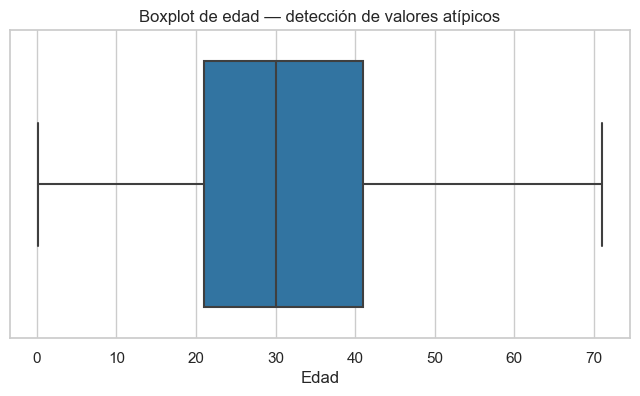

In [41]:
# Crear el boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['age'])
plt.title("Boxplot de edad — detección de valores atípicos")
plt.xlabel("Edad")
plt.show()

In [42]:

# Imputar edad con la mediana
df['age'].fillna(df['age'].median(), inplace=True)


- La edad (age) es una variable numérica continua.
- Usamos la mediana porque es más robusta frente a valores extremos o atípicos (outliers) que la media.
- Así evitamos que edades muy altas o muy bajas afecten el valor que usamos para reemplazar los NaN.

Sí. En estadística, la **edad** se considera una **variable cuantitativa continua**, porque:
- Se puede medir en unidades cada vez más pequeñas (años, meses, días, horas).
- No tiene "saltos fijos" entre valores posibles como sí ocurre con variables discretas.

Aunque en este dataset la mayoría de las edades están redondeadas a números enteros, algunas incluyen decimales (como 0.9167), lo que confirma que se trata de una variable **medida y continua**, no contada.

In [43]:

# Imputar 'embarked' con el valor más frecuente
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)


¿Por qué usamos la moda para 'embarked'?
La columna embarked indica el puerto de embarque, y es categórica.

Usamos la moda (el valor más frecuente) porque:
- Tiene sentido reemplazar un valor faltante con el valor que más se repite.
- Es una forma común de imputar variables categóricas sin distorsionar la distribución.

Este tipo de imputación mantiene el tamaño del dataset y permite continuar con el análisis sin eliminar datos que podrían ser útiles en otras variables.

## Medidas descriptivas

In [44]:

# Media, mediana, moda
df['age'].mean(), df['age'].median(), df['age'].mode()[0]


(30.57615594512195, 30.0, 30.0)

In [45]:

# Varianza, desviación estándar, rango
df['age'].var(), df['age'].std(), df['age'].max() - df['age'].min()


(105.20254808560918, 10.25682933881661, 70.8333)

In [46]:

# Cuartiles
df['age'].quantile([0.25, 0.5, 0.75])


0.25    30.0
0.50    30.0
0.75    30.0
Name: age, dtype: float64

Los tres cuartiles (Q1, Q2 y Q3) tienen el mismo valor: **30.0**. Esto indica que:

- Al menos el 75% de los pasajeros tiene una edad menor o igual a 30 años.
- El **50% central de los datos (IQR)** está completamente concentrado en un solo valor: 30.0
- Es probable que haya muchos pasajeros con esa edad exacta, o que los datos hayan sido redondeados o agrupados de forma inusual.

Este tipo de comportamiento es poco común y sugiere que:
- La variable `age` podría tener muchos valores repetidos (por ejemplo, muchas edades iguales a 30).
- Puede haber sido **censurada**, redondeada o imputada en grandes bloques.

## Visualización de la distribución

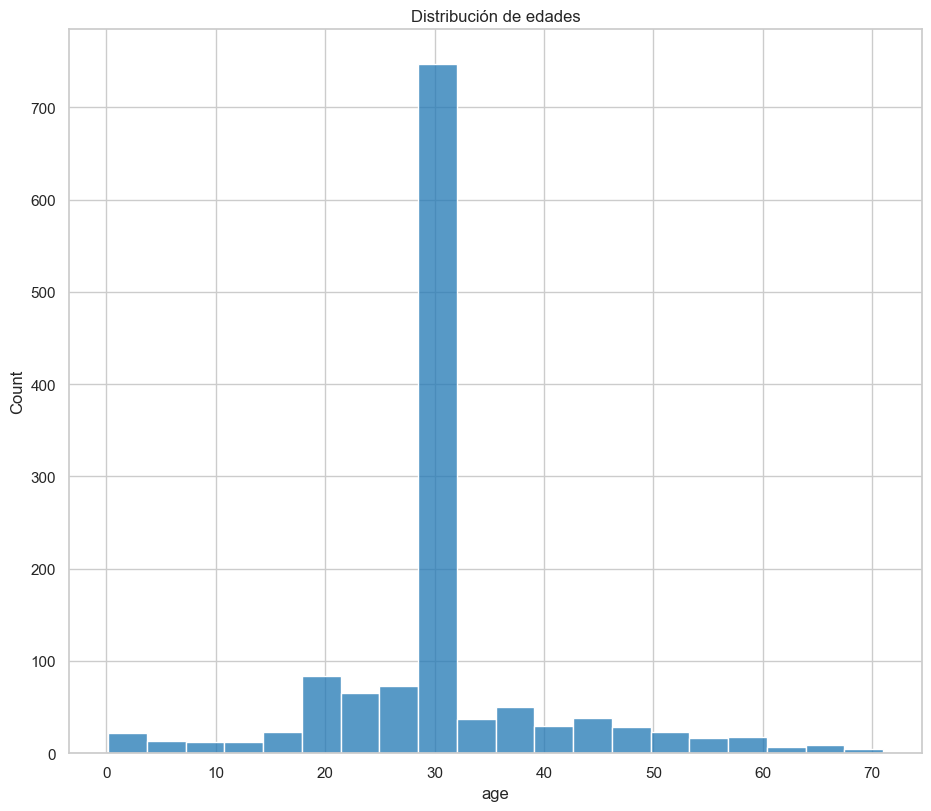

In [47]:

# Histograma de la distribución de edades
sns.histplot(df['age'], bins=20)
plt.title("Distribución de edades")
plt.show()


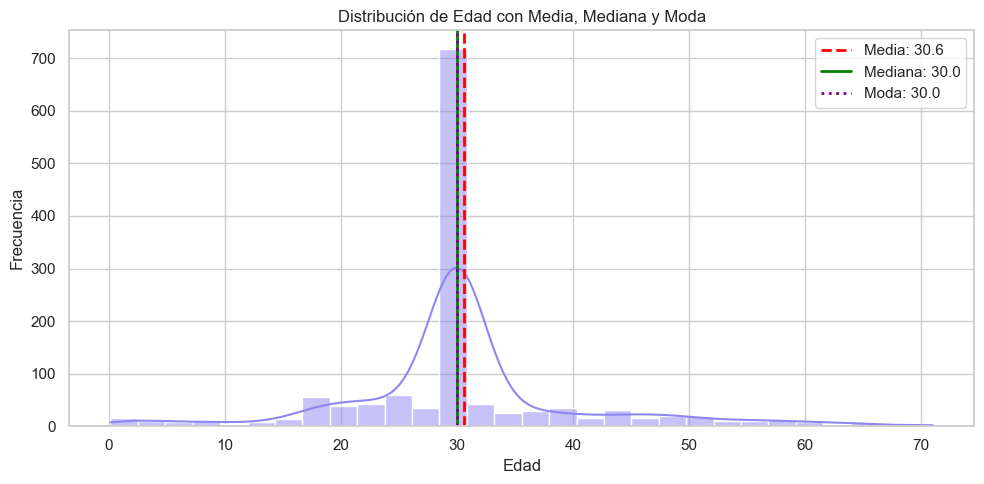

In [48]:
# Calcular medidas de localización
media = df['age'].mean()
mediana = df['age'].median()
moda = df['age'].mode()[0]

# Crear el histograma con líneas para media, mediana y moda
plt.figure(figsize=(10, 5))
sns.histplot(df['age'], bins=30, kde=True, color='#8F87F1')

plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.1f}')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.1f}')
plt.axvline(moda, color='purple', linestyle=':', linewidth=2, label=f'Moda: {moda:.1f}')

plt.title('Distribución de Edad con Media, Mediana y Moda')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

## ¿Por qué el histograma de edades se ve tan concentrado en 30?

Antes de imputar los valores faltantes, la columna `age` tenía:

- 1313 registros en total
- ❌ 680 valores faltantes (más del 50%)
- ✅ Solo 633 valores reales

Decidimos **rellenar los valores faltantes usando la mediana**, que en este caso es **30.0**. Además, la moda (valor más frecuente) también era 30, lo cual hizo que ese valor fuera aún más dominante en el conjunto final.

### ¿Qué efecto tuvo esto?

- Al reemplazar **más de la mitad de los valores faltantes con 30**, generamos un gran **pico en el histograma** en ese valor.
- Esto hace que la distribución se vea **concentrada o aplastada en el centro**, reduciendo la diversidad y ocultando la dispersión original.
- También puede hacer que los **cuartiles colapsen en un solo valor**, como se observó en nuestro análisis.

### Conclusión

Este comportamiento es común cuando se imputan muchos valores con un solo número. Por eso, aunque la mediana es una opción válida, **hay que interpretar los resultados con cuidado**, especialmente en gráficos y medidas de tendencia central.



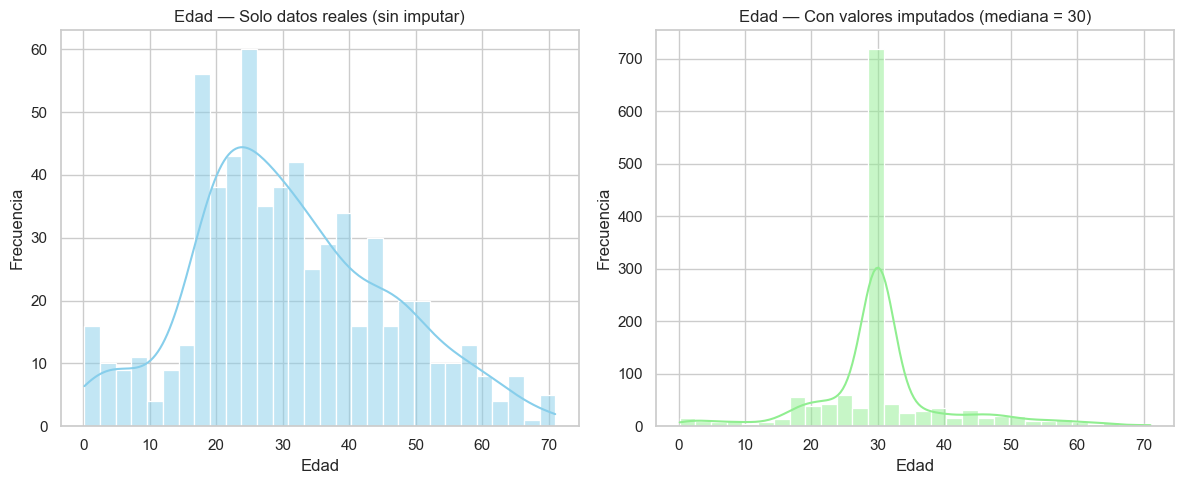

In [49]:
# Crear histogramas comparativos: con y sin imputación

# Datos originales sin imputar
df_original = pd.read_csv("titanic.csv")
ages_original = df_original['age'].dropna()

# Datos con imputación (mediana = 30)
df_imputado = df_original.copy()
df_imputado['age'] = df_imputado['age'].fillna(df_imputado['age'].median())

# Crear gráfico comparativo
plt.figure(figsize=(12, 5))

# Histograma sin imputación
plt.subplot(1, 2, 1)
sns.histplot(ages_original, bins=30, kde=True, color='skyblue')
plt.title("Edad — Solo datos reales (sin imputar)")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

# Histograma con imputación
plt.subplot(1, 2, 2)
sns.histplot(df_imputado['age'], bins=30, kde=True, color='lightgreen')
plt.title("Edad — Con valores imputados (mediana = 30)")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()


In [57]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, skew, kurtosis, probplot

In [ ]:
stat, p = shapiro(df_imputado['age'])
print(f"Estadístico Shapiro-Wilk: {stat:.3f}")
print(f"p-valor: {p:.3f}")
if p < 0.05:
    print("Los datos NO siguen una distribución normal.")
else:
    print("No se rechaza la normalidad (distribución normal posible).")

Estadístico Shapiro-Wilk: 0.832
p-valor: 0.000
Los datos NO siguen una distribución normal.


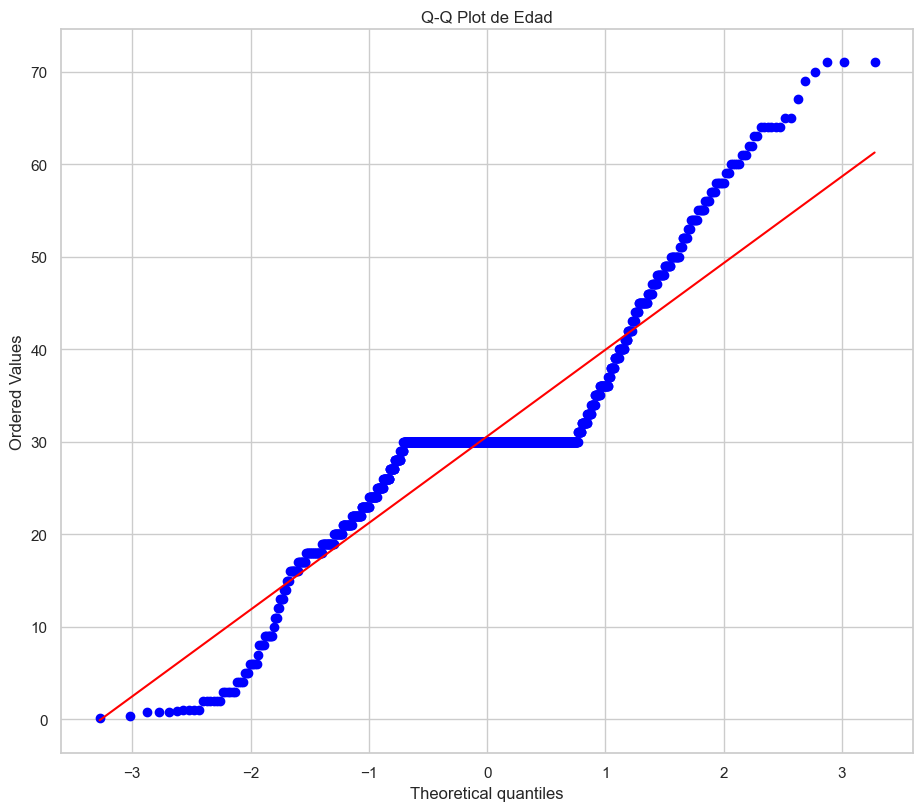

In [60]:
probplot(df_imputado['age'], dist="norm", plot=plt)
plt.title("Q-Q Plot de Edad")
plt.show()

**Diagrama de caja**

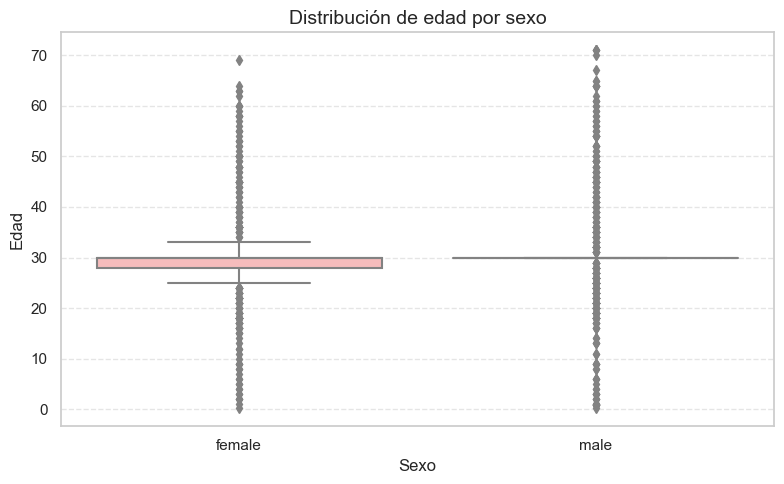

In [50]:

# Crear boxplot con colores personalizados por sexo
plt.figure(figsize=(8, 5))
sns.boxplot(x='sex', y='age', data=df, palette=sex_color)

plt.title("Distribución de edad por sexo", fontsize=14)
plt.xlabel("Sexo", fontsize=12)
plt.ylabel("Edad", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


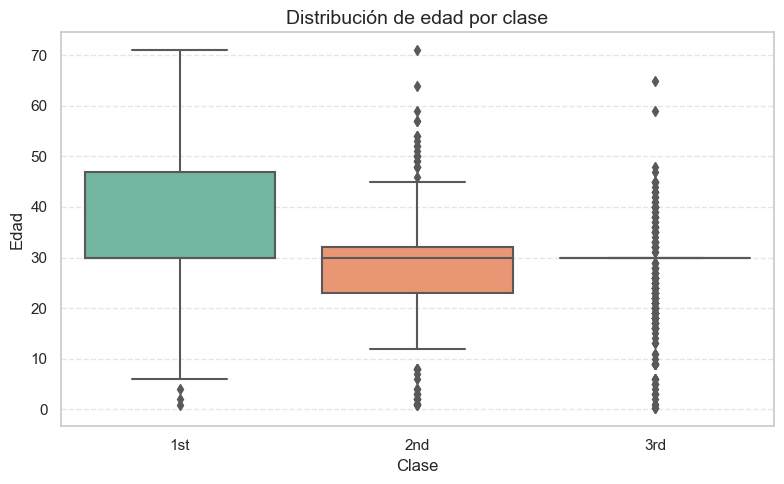

In [56]:
# Crear boxplot con colores personalizados por sexo
plt.figure(figsize=(8, 5))
sns.boxplot(x='passenger_class', y='age', data=df, palette='Set2')

plt.title("Distribución de edad por clase", fontsize=14)
plt.xlabel("Clase", fontsize=12)
plt.ylabel("Edad", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

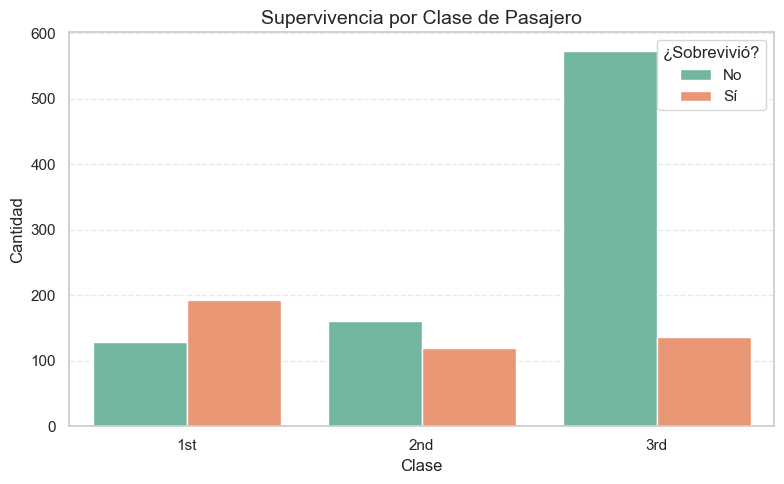

In [51]:
# Supervivencia por clase
plt.figure(figsize=(8, 5))
sns.countplot(x='passenger_class', hue='survive', data=df, palette='Set2')
plt.title("Supervivencia por Clase de Pasajero", fontsize=14)
plt.xlabel("Clase", fontsize=12)
plt.ylabel("Cantidad", fontsize=12)
plt.legend(title="¿Sobrevivió?", labels=["No", "Sí"])
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


El gráfico de barras muestra la relación entre la clase del pasajero y su probabilidad de supervivencia. Se observa claramente que los pasajeros de **primera clase (`1st`) tuvieron una tasa de supervivencia significativamente mayor** en comparación con los de segunda (`2nd`) y especialmente tercera clase (`3rd`). Esta diferencia puede deberse al acceso prioritario a los botes salvavidas, mejores ubicaciones en el barco o condiciones sociales que influyeron en el rescate. La **clase 3** no solo tuvo más pasajeros, sino también una proporción más alta de personas que no sobrevivieron.


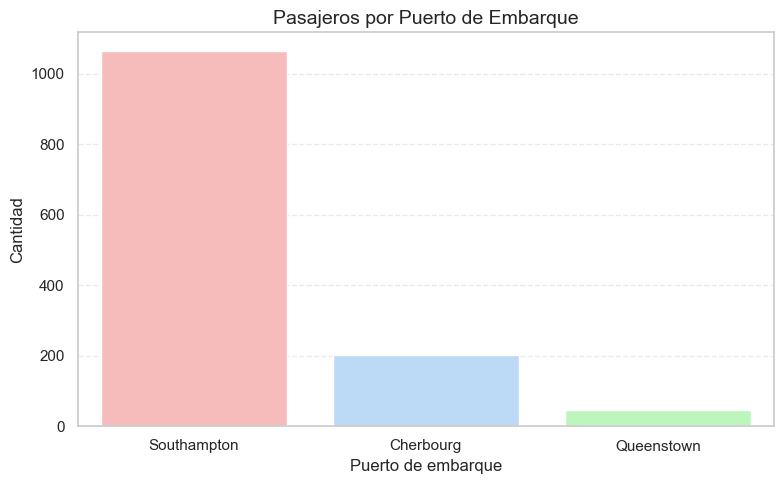

In [52]:
# Gráfico de conteo por puerto de embarque
plt.figure(figsize=(8, 5))
sns.countplot(x='embarked', data=df, palette=embarked_color)
plt.title("Pasajeros por Puerto de Embarque", fontsize=14)
plt.xlabel("Puerto de embarque", fontsize=12)
plt.ylabel("Cantidad", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Este gráfico muestra la cantidad de pasajeros que abordaron el Titanic desde cada puerto. La mayoría de los pasajeros **embarcaron en Southampton**, seguido por Cherbourg y, en menor medida, Queenstown. Esta distribución no solo refleja las rutas comerciales del barco, sino que también puede relacionarse con las características sociales y económicas de los pasajeros. Por ejemplo, muchos de los pasajeros de clase baja (3rd class) embarcaron en Southampton, lo que influye también en la distribución de supervivencia y clases.


C:\Users\mag_l\AppData\Local\Temp\ipykernel_18172\3894290210.py:20: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.swarmplot(x='sex', y='age', data=df, palette=sex_color, size=3)
c:\Users\mag_l\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:3544: UserWarning: 37.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\mag_l\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:3544: UserWarning: 49.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\mag_l\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:3544: UserWarning: 41.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\mag_l\AppData\Local

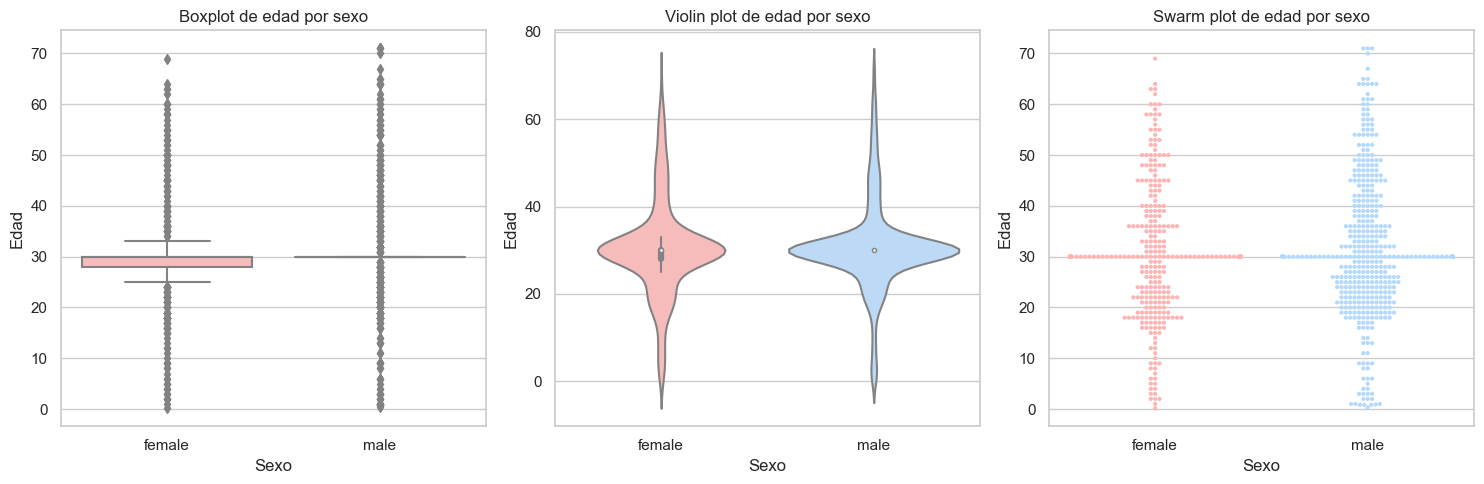

In [53]:
# Crear figura con 3 subgráficos para comparar métodos de visualización de dispersión
plt.figure(figsize=(15, 5))

# Boxplot
plt.subplot(1, 3, 1)
sns.boxplot(x='sex', y='age', data=df, palette=sex_color)
plt.title("Boxplot de edad por sexo")
plt.xlabel("Sexo")
plt.ylabel("Edad")

# Violin plot
plt.subplot(1, 3, 2)
sns.violinplot(x='sex', y='age', data=df, palette=sex_color)
plt.title("Violin plot de edad por sexo")
plt.xlabel("Sexo")
plt.ylabel("Edad")

# Swarm plot
plt.subplot(1, 3, 3)
sns.swarmplot(x='sex', y='age', data=df, palette=sex_color, size=3)
plt.title("Swarm plot de edad por sexo")
plt.xlabel("Sexo")
plt.ylabel("Edad")

plt.tight_layout()
plt.show()

## Comparación de medidas de dispersión: edad por sexo

Las siguientes tres gráficas nos permiten observar cómo se distribuye la edad de los pasajeros según su sexo, y cómo se manifiestan distintas **medidas de dispersión**:



### Boxplot (izquierda)

El **boxplot** muestra de forma clara:
- La **mediana** (línea central dentro de la caja)
- El **rango intercuartílico (IQR)**: desde el cuartil 1 (Q1) hasta el cuartil 3 (Q3)
- Los **bigotes** que representan el rango típico de los datos
- Los **outliers** (valores atípicos) marcados como puntos fuera de los bigotes

Este gráfico nos ayuda a **comparar la variabilidad** entre grupos. Por ejemplo, si la caja de mujeres es más ancha que la de hombres, hay mayor dispersión en ese grupo.



### Violin plot (centro)

El **violin plot** es una combinación entre boxplot y gráfico de densidad. Muestra:
- Las mismas referencias del boxplot (mediana, IQR)
- Una curva que indica **dónde se concentran más los datos**

Si el gráfico es más ancho en ciertas zonas, es porque **más pasajeros tenían esas edades**. Esto permite ver **asimetrías o concentraciones inusuales**.



### Strip plot (derecha)

El **strip plot** representa **cada pasajero como un punto**, con una ligera dispersión horizontal para evitar que se encimen:
- Permite observar la **distribución real y repetición de edades**
- Nos muestra claramente si hay muchos valores iguales (como los 30 años)
- Es útil para ver si los datos están **agrupados o dispersos**

---

### Conclusión

Estas tres representaciones permiten **visualizar y comparar la dispersión** de la edad entre hombres y mujeres.  
Mientras que el boxplot resume los datos en términos de cuartiles y valores extremos, el violin plot nos da una idea de la **forma de la distribución**, y el strip plot nos muestra **la dispersión individual de los datos**.

Combinar estas herramientas ayuda a tener una **visión más completa y didáctica de la variabilidad en los datos**.


In [54]:
df.to_csv("titanic_limpio.csv",index=False)